<a href="https://colab.research.google.com/github/FabioPira/TelecomX_LATAM/blob/main/TelecomX_LATAM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Extracción(E - Extract) #

El objetivo de este análisis es explorar el comportamiento de los clientes y detectar patrones asociados a la evasión, utilizando variables relacionadas con características del cliente, servicios contratados, costos y condiciones del contrato.

A través del análisis exploratorio de datos se busca identificar factores que incrementan o reducen la probabilidad de cancelación, proporcionando información valiosa para la toma de decisiones.

In [205]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [206]:
import os

os.listdir('//content/drive/MyDrive/Colab Notebooks')

['TelecomX_Data.json',
 'Untitled0.ipynb',
 'Inmuebles_cdmx.ipynb',
 'inmuebles_cdmx.ipynb',
 'Untitled1.ipynb',
 'Copia de AluraStoreLatam.ipynb',
 'TelecomX_LATAM.ipynb']

In [207]:
import json

ruta = '/content/drive/MyDrive/Colab Notebooks/TelecomX_Data.json'

with open(ruta, 'r') as archivo:
    datos = json.load(archivo)

print(type(datos))


<class 'list'>


In [208]:
import pandas as pd

df = pd.DataFrame(datos)

df.head()


,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


## Limpieza y Tratamiento de Datos ##

Durante esta etapa se realizaron diferentes procesos para asegurar que los datos estuvieran listos para el análisis.

In [209]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerID  7267 non-null   object
 1   Churn       7267 non-null   object
 2   customer    7267 non-null   object
 3   phone       7267 non-null   object
 4   internet    7267 non-null   object
 5   account     7267 non-null   object
dtypes: object(6)
memory usage: 340.8+ KB


In [210]:
df.columns

Index(['customerID', 'Churn', 'customer', 'phone', 'internet', 'account'], dtype='object')

# Verificación de tipos de datos #

In [211]:
import pandas as pd
import json

# Cargar el archivo
with open('/content/drive/MyDrive/Colab Notebooks/TelecomX_Data.json') as f:
    data = json.load(f)

# Normalizar el JSON
df = pd.json_normalize(data)

df.head()


,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


In [212]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   object 
 1   Churn                      7267 non-null   object 
 2   customer.gender            7267 non-null   object 
 3   customer.SeniorCitizen     7267 non-null   int64  
 4   customer.Partner           7267 non-null   object 
 5   customer.Dependents        7267 non-null   object 
 6   customer.tenure            7267 non-null   int64  
 7   phone.PhoneService         7267 non-null   object 
 8   phone.MultipleLines        7267 non-null   object 
 9   internet.InternetService   7267 non-null   object 
 10  internet.OnlineSecurity    7267 non-null   object 
 11  internet.OnlineBackup      7267 non-null   object 
 12  internet.DeviceProtection  7267 non-null   object 
 13  internet.TechSupport       7267 non-null   objec

# Verificación de Inconsistencias #

In [213]:
df.isnull().sum()

,0
customerID,0
Churn,0
customer.gender,0
customer.SeniorCitizen,0
customer.Partner,0
customer.Dependents,0
customer.tenure,0
phone.PhoneService,0
phone.MultipleLines,0
internet.InternetService,0


In [214]:
df['customerID'].duplicated().sum()

np.int64(0)

In [215]:
df['customerID'].duplicated().sum()

np.int64(0)

In [216]:
df.dtypes

,0
customerID,object
Churn,object
customer.gender,object
customer.SeniorCitizen,int64
customer.Partner,object
customer.Dependents,object
customer.tenure,int64
phone.PhoneService,object
phone.MultipleLines,object
internet.InternetService,object


In [217]:
df['account.Contract'].unique()
df['internet.InternetService'].unique()
df['phone.MultipleLines'].unique()


array(['No', 'Yes', 'No phone service'], dtype=object)

In [218]:
df['account.Charges.Total'] = pd.to_numeric(
    df['account.Charges.Total'],
    errors='coerce'
)


In [219]:
df['account.Charges.Total'] = df['account.Charges.Total'].fillna(
    df['account.Charges.Monthly'] * df['customer.tenure']
)


In [220]:
df['account.Charges.Total'].isna().sum()



np.int64(0)

In [221]:
df[df['account.Charges.Total'].isna()][
    ['customerID', 'customer.tenure', 'account.Charges.Monthly', 'account.Charges.Total']
]


,customerID,customer.tenure,account.Charges.Monthly,account.Charges.Total


In [222]:
df.head()


,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40


In [223]:
df.duplicated().sum()


np.int64(0)

In [224]:
for col in df.select_dtypes(include='object'):
    print(f"\nColumna: {col}")
    print(df[col].unique())



Columna: customerID
['0002-ORFBO' '0003-MKNFE' '0004-TLHLJ' ... '9992-UJOEL' '9993-LHIEB'
 '9995-HOTOH']

Columna: Churn
['No' 'Yes' '']

Columna: customer.gender
['Female' 'Male']

Columna: customer.Partner
['Yes' 'No']

Columna: customer.Dependents
['Yes' 'No']

Columna: phone.PhoneService
['Yes' 'No']

Columna: phone.MultipleLines
['No' 'Yes' 'No phone service']

Columna: internet.InternetService
['DSL' 'Fiber optic' 'No']

Columna: internet.OnlineSecurity
['No' 'Yes' 'No internet service']

Columna: internet.OnlineBackup
['Yes' 'No' 'No internet service']

Columna: internet.DeviceProtection
['No' 'Yes' 'No internet service']

Columna: internet.TechSupport
['Yes' 'No' 'No internet service']

Columna: internet.StreamingTV
['Yes' 'No' 'No internet service']

Columna: internet.StreamingMovies
['No' 'Yes' 'No internet service']

Columna: account.Contract
['One year' 'Month-to-month' 'Two year']

Columna: account.PaperlessBilling
['Yes' 'No']

Columna: account.PaymentMethod
['Mailed che

In [225]:
(df['Churn'] == '').sum()


np.int64(224)

In [226]:
df = df[df['Churn'] != '']


In [227]:
df['Churn'].unique()
df.shape


(7043, 21)

## TAnálisis Exploratorio de Datos (EDA) ##

Se realizaron diferentes análisis estadísticos y visualizaciones para comprender mejor el comportamiento de los clientes.


In [228]:
df['Cuentas_Diarias'] = df['account.Charges.Monthly'] / 30


In [229]:
df[['account.Charges.Monthly', 'Cuentas_Diarias']].head()


,account.Charges.Monthly,Cuentas_Diarias
0,65.6,2.186667
1,59.9,1.996667
2,73.9,2.463333
3,98.0,3.266667
4,83.9,2.796667


## Estandarización y transformación de datos ##


In [230]:
df["Churn"].value_counts()


,count
Churn,
No,5174
Yes,1869


In [231]:
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})
df["customer.gender"] = df["customer.gender"].map({
    "Female": 0,
    "Male": 1
})
df["customer.Partner"] = df["customer.Partner"].map({
    "Yes": 1,
    "No": 0
})
df["customer.Dependents"] = df["customer.Dependents"].map({
    "Yes": 1,
    "No": 0
})
df["account.PaperlessBilling"] = df["account.PaperlessBilling"].map({
    "Yes": 1,
    "No": 0
})




In [232]:
for col in df.columns:
    print(col, df[col].unique())


customerID ['0002-ORFBO' '0003-MKNFE' '0004-TLHLJ' ... '9992-UJOEL' '9993-LHIEB'
 '9995-HOTOH']
Churn [0 1]
customer.gender [0 1]
customer.SeniorCitizen [0 1]
customer.Partner [1 0]
customer.Dependents [1 0]
customer.tenure [ 9  4 13  3 71 63  7 65 54 72  5 56 34  1 45 50 23 55 26 69 37 49 66 67
 20 43 59 12 27  2 25 29 14 35 64 39 40 11  6 30 70 57 58 16 32 33 10 21
 61 15 44 22 24 19 47 62 46 52  8 60 48 28 41 53 68 31 36 17 18 51 38 42
  0]
phone.PhoneService ['Yes' 'No']
phone.MultipleLines ['No' 'Yes' 'No phone service']
internet.InternetService ['DSL' 'Fiber optic' 'No']
internet.OnlineSecurity ['No' 'Yes' 'No internet service']
internet.OnlineBackup ['Yes' 'No' 'No internet service']
internet.DeviceProtection ['No' 'Yes' 'No internet service']
internet.TechSupport ['Yes' 'No' 'No internet service']
internet.StreamingTV ['Yes' 'No' 'No internet service']
internet.StreamingMovies ['No' 'Yes' 'No internet service']
account.Contract ['One year' 'Month-to-month' 'Two year']
account.P

In [233]:
df["Churn"].value_counts()


,count
Churn,
0,5174
1,1869


# Carga y análisis(L - Load & Analysis) #

In [234]:
df.describe()

,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,account.PaperlessBilling,account.Charges.Monthly,account.Charges.Total,Cuentas_Diarias
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.265370,0.504756,0.162147,0.483033,0.299588,32.371149,0.592219,64.761692,2279.734304,2.158723
std,0.441561,0.500013,0.368612,0.499748,0.458110,24.559481,0.491457,30.090047,2266.794470,1.003002
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,18.250000,0.000000,0.608333
25%,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,0.000000,35.500000,398.550000,1.183333
50%,0.000000,1.000000,0.000000,0.000000,0.000000,29.000000,1.000000,70.350000,1394.550000,2.345000
75%,1.000000,1.000000,0.000000,1.000000,1.000000,55.000000,1.000000,89.850000,3786.600000,2.995000
max,1.000000,1.000000,1.000000,1.000000,1.000000,72.000000,1.000000,118.750000,8684.800000,3.958333


# Distribución de cargos mensuales #

Se utilizó un diagrama de caja (boxplot) para analizar la distribución de los cargos mensuales. El análisis mostró que la mayoría de los clientes paga valores entre rangos medios, con una mediana cercana a los niveles promedio del servicio.

Esto indica que existe variabilidad en los planes contratados, lo cual puede influir en la decisión de permanecer o cancelar el servicio.

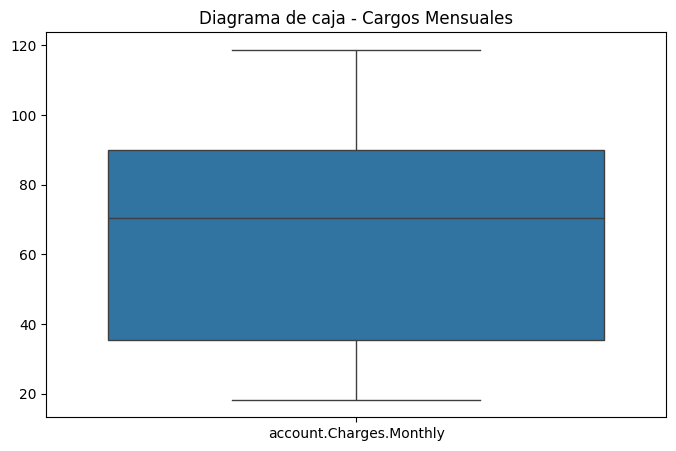

In [235]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.boxplot(data=df[['account.Charges.Monthly']])

plt.title('Diagrama de caja - Cargos Mensuales')
plt.show()

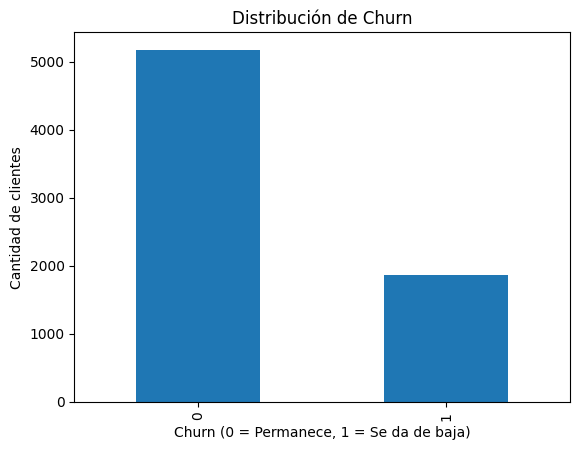

In [236]:
import matplotlib.pyplot as plt

df["Churn"].value_counts().plot(kind="bar")
plt.title("Distribución de Churn")
plt.xlabel("Churn (0 = Permanece, 1 = Se da de baja)")
plt.ylabel("Cantidad de clientes")
plt.show()


In [237]:
df["Churn"].value_counts(normalize=True)


,proportion
Churn,
0,0.73463
1,0.26537


Aproximadamente 1 de cada 4 clientes se va

In [238]:
df.head()

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total,Cuentas_Diarias
0,0002-ORFBO,0,0,0,1,1,9,Yes,No,DSL,...,No,Yes,Yes,No,One year,1,Mailed check,65.6,593.30,2.186667
1,0003-MKNFE,0,1,0,0,0,9,Yes,Yes,DSL,...,No,No,No,Yes,Month-to-month,0,Mailed check,59.9,542.40,1.996667
2,0004-TLHLJ,1,1,0,0,0,4,Yes,No,Fiber optic,...,Yes,No,No,No,Month-to-month,1,Electronic check,73.9,280.85,2.463333
3,0011-IGKFF,1,1,1,1,0,13,Yes,No,Fiber optic,...,Yes,No,Yes,Yes,Month-to-month,1,Electronic check,98.0,1237.85,3.266667
4,0013-EXCHZ,1,0,1,1,0,3,Yes,No,Fiber optic,...,No,Yes,Yes,No,Month-to-month,1,Mailed check,83.9,267.40,2.796667


In [239]:
df.groupby("customer.gender")["Churn"].mean()


,Churn
customer.gender,
0,0.269209
1,0.261603


In [240]:
df.groupby("account.Contract")["Churn"].mean()


,Churn
account.Contract,
Month-to-month,0.427097
One year,0.112695
Two year,0.028319


In [246]:
import plotly.express as px

# Agrupar datos
contract_churn = df.groupby(['account.Contract', 'Churn']).size().reset_index(name='count')

# Crear gráfico
fig = px.bar(
    contract_churn,
    x='account.Contract',
    y='count',
    color='Churn',
    barmode='group',
    title='Tipo de Contrato vs Evasión de Clientes (Churn)',
    labels={
        'account.Contract': 'Tipo de Contrato',
        'count': 'Número de Clientes',
        'Churn': 'Churn'
    }
)

fig.show()

Si Telecom X quiere reducir churn:

Debe crear estrategias para:

Incentivar contratos anuales

Ofrecer descuentos por permanencia

Identificar clientes mensuales con alto riesgo

In [242]:
df.groupby("account.PaymentMethod")["Churn"].mean()


,Churn
account.PaymentMethod,
Bank transfer (automatic),0.167098
Credit card (automatic),0.152431
Electronic check,0.452854
Mailed check,0.191067


Esto sugiere que:

Los clientes que utilizan pagos automáticos tienden a tener mayor estabilidad y permanencia en el servicio.

Los clientes que pagan con electronic check pueden tener menos compromiso con el servicio, lo que aumenta la probabilidad de cancelación.

Conclusión para el negocio

El método de pago puede ser un factor importante para identificar clientes con mayor riesgo de evasión, y podría ser útil incentivar métodos de pago automáticos para mejorar la retención de clientes.

In [243]:
df.groupby("internet.InternetService")["Churn"].mean()


,Churn
internet.InternetService,
DSL,0.189591
Fiber optic,0.418928
No,0.074050


los clientes con fibra óptica los que presentan mayor probabilidad de cancelar, mientras que los clientes sin servicio de internet muestran mayor permanencia.

# Conteo de evasión por variables numéricas #

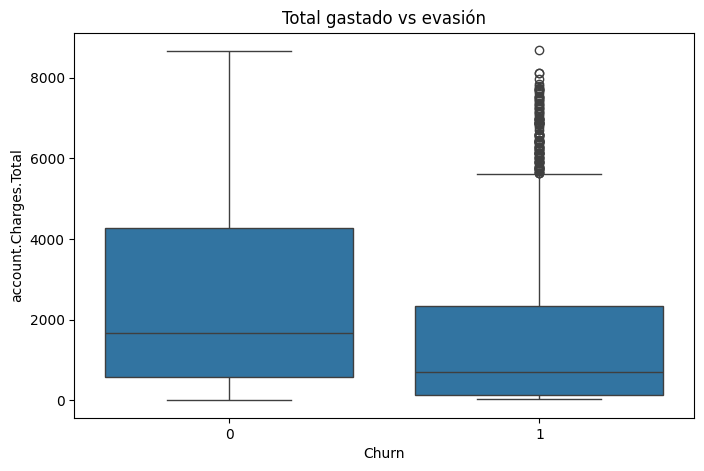

In [244]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.boxplot(x="Churn", y="account.Charges.Total", data=df)

plt.title("Total gastado vs evasión")
plt.show()

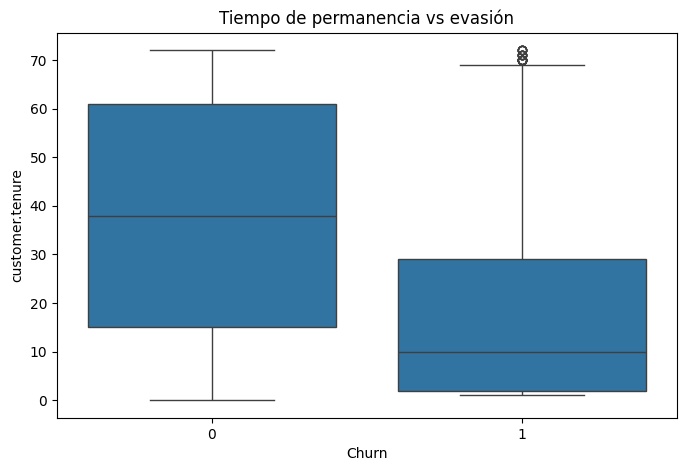

In [245]:
plt.figure(figsize=(8,5))
sns.boxplot(x="Churn", y="customer.tenure", data=df)

plt.title("Tiempo de permanencia vs evasión")
plt.show()

Los primeros meses del cliente son críticos para la retención.

Si un cliente permanece más tiempo, la probabilidad de evasión disminuye considerablemente.

# Conclusiones e Insights #

A partir del análisis realizado se identificaron varios factores importantes relacionados con la evasión de clientes.

Los principales hallazgos fueron:

Los contratos mensuales presentan la mayor tasa de cancelación.

Los clientes que utilizan electronic check muestran mayor probabilidad de evasión.

El tiempo de permanencia es uno de los factores más influyentes en la retención.

Los clientes que cancelan suelen tener menor gasto total, lo que refleja menor permanencia.

El tipo de servicio de internet también presenta diferencias en la tasa de churn.

En general, los resultados sugieren que la estabilidad contractual, los métodos de pago automáticos y una mayor permanencia reducen significativamente la probabilidad de cancelación.

# Recomendaciones #

Con base en los resultados obtenidos, se proponen las siguientes estrategias para reducir la evasión de clientes:

Incentivar contratos a largo plazo

Ofrecer beneficios o descuentos a clientes que opten por contratos de uno o dos años, lo cual puede aumentar la retención.

Promover métodos de pago automáticos

Incentivar el uso de tarjetas o transferencias automáticas, ya que estos métodos se asocian con menor evasión.

Fortalecer la experiencia en los primeros meses

Implementar programas de acompañamiento o atención personalizada para clientes nuevos, reduciendo el riesgo de cancelación temprana.

Analizar la experiencia de usuarios de fibra óptica

Revisar posibles problemas relacionados con precio, calidad del servicio o expectativas del cliente en este segmento.

# Conclusión final #

El análisis permitió identificar patrones claros en el comportamiento de los clientes, demostrando que factores como tipo de contrato, método de pago y tiempo de permanencia tienen una fuerte relación con la evasión.

Estos hallazgos pueden ser utilizados por la empresa para desarrollar estrategias de retención más efectivas y mejorar la estabilidad de su base de clientes.